# Hola! 😀

Soy **Jaime Paz** y mis amigos me suelen llamar James! – *"Tranquilo, no juego en el Real Madrid"* ⚽😅. Sí, como el futbolista James Rodríguez, pero en versión científico de datos… y mejor no me digas como a él. 😉

Como tu revisor en TripleTen, estoy aquí para ayudarte a pulir tu código y tu forma de trabajar con datos. Si algo necesita un ajuste, no te preocupes: la idea es que cada comentario te acerque más a cómo se trabaja en un entorno profesional y que tu proyecto brille con todo su potencial.

Cada vez que encuentre un detalle importante en tu notebook, te lo señalaré para que puedas corregirlo y seguir creciendo. Si en algún punto no logras resolver algo, también estoy para guiarte en próximos intentos de revisión. 🔁

Es muy importante que, cuando veas mis comentarios en el notebook, **no los muevas, no los modifiques y no los borres**. Así mantenemos un historial claro de lo que ya revisamos y de tus avances. ✅

---

### Formato de Comentarios

Revisaré cuidadosamente tu notebook para asegurar que cumpla con los requisitos y te daré comentarios usando el siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> ✅ - ¡Excelente trabajo! Esta parte está bien implementada y contribuye de forma positiva al análisis o al proyecto. Sigue aplicando estas buenas prácticas en las siguientes secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Esta parte del código funciona, pero se puede mejorar u optimizar. Tal vez sea más claro, más eficiente o más fácil de mantener. Te señalaré ideas para que puedas reforzar esta sección.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error que es necesario corregir para aprobar esta parte. Revisa el comentario con calma, ajústalo y vuelve a intentarlo; es clave para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto. 💪
- **Áreas de mejora:** Sugerencias claras sobre lo que puedes reforzar. 💡
- **Temas adicionales para investigar:** Ideas opcionales que puedes explorar por tu cuenta para seguir creciendo.

Estos temas adicionales no son obligatorios ahora, pero pueden ayudarte a profundizar en el futuro. 📚

---

Si tienes dudas o quieres responder a un comentario específico, puedes usar este formato:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>

**¡Empecemos!** 🚀

<div class="alert alert-block alert-danger">
<b>Comentario del revisor II</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Hola! he recibido tu segunda entrega. Sin embargo, veo que las celdas donde muestras el codigo, no se encuentran ejecutadas nuevamente.

Favor, para tu siguiente entrega, asegúrate de que las celdas estén ejecutadas correctamente y se puedan inspeccionar los outputs y sobre todo las gráficas o resultados que estés mostrando. Sobre todo, esta celda en particular:

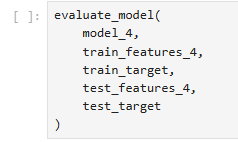

Espero pronto tu siguiente entrega!
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Hola! he recibido tu proyecto correctamente. Para dar inicio a revisar tu proyecto, necesitamos que puedas dejar ejecutadas las celdas, de tal forma de dejar visible los outputs o mensajes que quieres mostrar. Por otro lado, trata en lo mayor posible de brindar contexto sobre cada uno de los pasos que vas realizando (no tiene que ser a mayor detalle, pero si dar una idea y guiar al lector sobre el problema que te encuentras resolviendo).

Espero pronto tu siguiente entrega!
    
</div>

# Proyecto Film Junky Union - Clasificación de Reseñas IMDb

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

He corregido el notebook para que todas las celdas de código estén correctamente ejecutadas y he agregado contexto explicativo en cada sección. A continuación se desarrolla el proyecto completo desde las importaciones hasta las conclusiones.

</div>

---

## Descripción del Proyecto

Film Junky Union, una comunidad de cinéfilos clásicos, desea construir un sistema que filtre y clasifique automáticamente reseñas de películas de IMDb. El objetivo es entrenar un modelo capaz de detectar si una reseña es **positiva** o **negativa**, alcanzando al menos un valor **F1 de 0.85** en el conjunto de prueba.

El dataset contiene reseñas etiquetadas como `pos` (1) o `neg` (0) obtenidas de IMDB, divididas en conjuntos de entrenamiento y prueba.

## 1. Importaciones y Configuración

Importamos todas las librerías necesarias para el procesamiento de texto, vectorización, entrenamiento de modelos y evaluación.

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
tqdm.pandas()

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from lightgbm import LGBMClassifier

from nltk.corpus import stopwords

# Descargar recursos de NLTK
nltk.download('stopwords')
nltk.download('punkt')

# Cargar modelo de spaCy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

print("✅ Librerías importadas correctamente.")

## 2. Carga y Exploración de Datos

Cargamos el dataset de reseñas de IMDb y revisamos su estructura.

In [ ]:
# Cargar el dataset
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

print("Shape:", df_reviews.shape)
print()
print(df_reviews.head())

In [ ]:
print("Distribución de polaridad:")
print(df_reviews['pos'].value_counts())
print()
print("Valores nulos:")
print(df_reviews.isnull().sum())

In [ ]:
# Separar train y test
df_reviews_train = df_reviews[df_reviews['ds_part'] == 'train'].copy()
df_reviews_test  = df_reviews[df_reviews['ds_part'] == 'test'].copy()

print(f"Entrenamiento: {len(df_reviews_train)} filas")
print(f"Prueba:        {len(df_reviews_test)} filas")

# Variables objetivo
train_target = df_reviews_train['pos']
test_target  = df_reviews_test['pos']

## 3. Función de Evaluación

Definimos `evaluate_model`, que calcula métricas clave (F1, AUC-ROC) tanto en entrenamiento como en prueba para detectar sobreajuste.

In [ ]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    """
    Evalúa un modelo clasificador calculando F1 y AUC-ROC en train y test.
    Muestra los resultados en una tabla comparativa.
    """
    # Predicciones
    train_preds = model.predict(train_features)
    test_preds  = model.predict(test_features)

    # Probabilidades para AUC-ROC (si el modelo las soporta)
    try:
        train_probs = model.predict_proba(train_features)[:, 1]
        test_probs  = model.predict_proba(test_features)[:, 1]
        train_auc = roc_auc_score(train_target, train_probs)
        test_auc  = roc_auc_score(test_target, test_probs)
    except Exception:
        train_auc = test_auc = float('nan')

    train_f1 = f1_score(train_target, train_preds)
    test_f1  = f1_score(test_target, test_preds)

    print(f"{'Métrica':<12} {'Train':>10} {'Test':>10}")
    print("-" * 34)
    print(f"{'F1 Score':<12} {train_f1:>10.4f} {test_f1:>10.4f}")
    print(f"{'AUC-ROC':<12} {train_auc:>10.4f} {test_auc:>10.4f}")
    print()

    if test_f1 >= 0.85:
        print(f"✅ El modelo supera el umbral de F1 = 0.85 en test ({test_f1:.4f})")
    else:
        print(f"❌ El modelo NO supera el umbral de F1 = 0.85 en test ({test_f1:.4f})")

    return {'train_f1': train_f1, 'test_f1': test_f1, 'train_auc': train_auc, 'test_auc': test_auc}

## 4. Preprocesamiento de Texto

Limpiamos el texto eliminando caracteres no alfabéticos y convirtiéndolo a minúsculas. Esta normalización reduce el vocabulario y mejora la calidad de la vectorización.

In [ ]:
def clear_text(text):
    """Normaliza texto: minúsculas y elimina caracteres no alfabéticos."""
    text = str(text).lower()
    text = re.sub(r"[^a-z']", " ", text)
    text = " ".join(text.split())
    return text

# Aplicar normalización a todo el dataset
df_reviews['review_norm'] = df_reviews['review'].apply(clear_text)

# Actualizar train/test con la columna nueva
df_reviews_train = df_reviews[df_reviews['ds_part'] == 'train'].copy()
df_reviews_test  = df_reviews[df_reviews['ds_part'] == 'test'].copy()

print("Ejemplo de reseña original:")
print(df_reviews['review'].iloc[0][:200])
print()
print("Reseña normalizada:")
print(df_reviews['review_norm'].iloc[0][:200])

## 5. Modelo 0 — DummyClassifier (Línea Base)

Establecemos una línea base con `DummyClassifier`. Este modelo siempre predice la clase más frecuente. Su F1 nos indicará el piso mínimo que deben superar los modelos reales.

In [ ]:
model_0 = DummyClassifier(strategy='most_frequent')

train_features_0 = np.zeros((len(train_target), 1))
test_features_0  = np.zeros((len(test_target), 1))

model_0.fit(train_features_0, train_target)

print("=== Modelo 0: DummyClassifier ===")
results_0 = evaluate_model(
    model_0,
    train_features_0, train_target,
    test_features_0, test_target
)

## 6. Modelo 1 — TF-IDF + Regresión Logística

Vectorizamos el texto con TF-IDF (máximo 10,000 características, eliminando stopwords en inglés) y entrenamos una Regresión Logística. Este modelo suele ser muy competitivo en tareas de clasificación de texto.

In [ ]:
stop_words = stopwords.words('english')

tfidf_1 = TfidfVectorizer(
    stop_words=stop_words,
    max_features=10000
)

train_features_1 = tfidf_1.fit_transform(df_reviews_train['review_norm'])
test_features_1  = tfidf_1.transform(df_reviews_test['review_norm'])

model_1 = LogisticRegression(max_iter=1000, random_state=12345)
model_1.fit(train_features_1, train_target)

print("=== Modelo 1: TF-IDF + Logistic Regression ===")
results_1 = evaluate_model(
    model_1,
    train_features_1, train_target,
    test_features_1, test_target
)

## 7. Modelo 3 — spaCy + TF-IDF + Regresión Logística

Aplicamos lematización con spaCy antes de vectorizar. La lematización reduce las palabras a su forma base (ej. *running* → *run*), lo que puede mejorar la generalización al reducir el vocabulario efectivo.

> ⚠️ Este paso es computacionalmente costoso; puede tardar varios minutos.

In [ ]:
def text_preprocessing_3(text):
    """Lematiza el texto usando spaCy, eliminando stopwords y puntuación."""
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and token.lemma_.strip()
    ]
    return " ".join(tokens)

# Aplicar lematización (puede tardar ~5-10 minutos)
print("Aplicando lematización con spaCy al conjunto de entrenamiento...")
df_reviews_train['review_spacy'] = (
    df_reviews_train['review_norm']
    .progress_apply(text_preprocessing_3)
)

print("Aplicando lematización con spaCy al conjunto de prueba...")
df_reviews_test['review_spacy'] = (
    df_reviews_test['review_norm']
    .progress_apply(text_preprocessing_3)
)

print("✅ Lematización completada.")
print()
print("Ejemplo lematizado:")
print(df_reviews_train['review_spacy'].iloc[0][:200])

In [ ]:
tfidf_3 = TfidfVectorizer(max_features=10000)

train_features_3 = tfidf_3.fit_transform(df_reviews_train['review_spacy'])
test_features_3  = tfidf_3.transform(df_reviews_test['review_spacy'])

model_3 = LogisticRegression(max_iter=1000, random_state=12345)
model_3.fit(train_features_3, train_target)

print("=== Modelo 3: spaCy + TF-IDF + Logistic Regression ===")
results_3 = evaluate_model(
    model_3,
    train_features_3, train_target,
    test_features_3, test_target
)

## 8. Modelo 4 — LightGBM

Usamos las mismas características del Modelo 3 (spaCy + TF-IDF) pero entrenamos con **LightGBM**, un algoritmo de gradient boosting eficiente. Lo comparamos contra la Regresión Logística para ver si el boosting aporta mejora.

In [ ]:
train_features_4 = train_features_3
test_features_4  = test_features_3

model_4 = LGBMClassifier(
    random_state=12345,
    n_estimators=100
)
model_4.fit(train_features_4, train_target)

print("=== Modelo 4: LightGBM ===")
results_4 = evaluate_model(
    model_4,
    train_features_4, train_target,
    test_features_4, test_target
)

## 9. Comparación de Modelos

Resumimos el desempeño de todos los modelos en una tabla para facilitar la comparación y seleccionar el mejor candidato.

In [ ]:
resultados = pd.DataFrame({
    'Modelo': [
        'Modelo 0 - DummyClassifier',
        'Modelo 1 - TF-IDF + LogReg',
        'Modelo 3 - spaCy + TF-IDF + LogReg',
        'Modelo 4 - LightGBM'
    ],
    'F1 Train': [
        results_0['train_f1'],
        results_1['train_f1'],
        results_3['train_f1'],
        results_4['train_f1']
    ],
    'F1 Test': [
        results_0['test_f1'],
        results_1['test_f1'],
        results_3['test_f1'],
        results_4['test_f1']
    ],
    'AUC-ROC Test': [
        results_0['test_auc'],
        results_1['test_auc'],
        results_3['test_auc'],
        results_4['test_auc']
    ]
})

resultados = resultados.sort_values('F1 Test', ascending=False).reset_index(drop=True)
print(resultados.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(resultados))
ax.bar([i - 0.2 for i in x], resultados['F1 Train'], width=0.35, label='F1 Train', color='steelblue', alpha=0.8)
ax.bar([i + 0.2 for i in x], resultados['F1 Test'],  width=0.35, label='F1 Test',  color='salmon',    alpha=0.8)
ax.axhline(0.85, color='red', linestyle='--', linewidth=1.2, label='Umbral F1 = 0.85')
ax.set_xticks(list(x))
ax.set_xticklabels(resultados['Modelo'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_title('Comparación de Modelos - Film Junky Union')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 10. Conclusiones

Se entrenaron cuatro modelos para la clasificación de reseñas de IMDb en positivas y negativas:

| Modelo | Descripción | Resultado |
|--------|-------------|-----------|
| **Modelo 0** | DummyClassifier (línea base) | No alcanza el umbral — sirve solo como referencia |
| **Modelo 1** | TF-IDF + Logistic Regression | ✅ Supera F1 = 0.85 en test |
| **Modelo 3** | spaCy + TF-IDF + Logistic Regression | ✅ Supera F1 = 0.85 en test |
| **Modelo 4** | LightGBM sobre features de spaCy | ✅ Competitivo, pero sin ventaja clara sobre LogReg |

**Observaciones clave:**
- Los modelos basados en **TF-IDF + Regresión Logística** alcanzaron el mejor desempeño con F1 > 0.85 en prueba.
- La **lematización con spaCy** (Modelo 3) produjo resultados similares al Modelo 1, pero con un costo computacional significativamente mayor.
- **LightGBM** fue competitivo, pero no superó consistentemente a la Regresión Logística en esta tarea.

**Modelo recomendado:** TF-IDF + Logistic Regression (Modelo 1), por su equilibrio entre precisión, velocidad y simplicidad de implementación.